In [1]:
import os
import random
import numpy as np
import tensorflow as tf

# 1. Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. Configure TensorFlow to use GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detected: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU found. Using CPU.")

2026-03-12 01:51:16.828573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773280277.054656      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773280277.117136      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773280277.630732      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773280277.630781      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773280277.630784      23 computation_placer.cc:177] computation placer alr

✅ GPU detected: /physical_device:GPU:0


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedsamir1598/glyphdataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ahmedsamir1598/glyphdataset


In [3]:
import os
from collections import Counter

# Path to the dataset
dataset_path = "/kaggle/input/datasets/ahmedsamir1598/glyphdataset/Dataset/Manual/Preprocessed"

total_images = 0
class_counts = {}

# Loop through each class folder
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        num_images = len(images)
        
        class_counts[class_name] = num_images
        total_images += num_images

# Total number of classes
total_classes = len(class_counts)

print("Total number of images:", total_images)
print("Total number of classes:", total_classes)

print("\nImages per class:")
for cls, count in sorted(class_counts.items()):
    print(f"{cls}: {count}")

Total number of images: 4210
Total number of classes: 10

Images per class:
20: 387
21: 360
22: 439
23: 424
3: 464
39: 402
41: 404
5: 455
7: 455
9: 420


In [4]:
import cv2
import os

# Define the standard size for pretrained models
IMG_SIZE = 224 

# Dictionary to store images by class
images_by_class = {}

# Iterate over existing classes
for class_name in class_counts.keys():
    class_folder = os.path.join(dataset_path, class_name)
    images_by_class[class_name] = []
    
    if not os.path.exists(class_folder):
        continue
        
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        
        # 1. Load image in color (BGR)
        img = cv2.imread(img_path)
        
        if img is not None:
            # 2. Convert to RGB (Required for Pretrained Models)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # 3. Resize to 224x224
            # We use INTER_CUBIC which is better for upscaling/maintaining line sharpness
            img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
            
            # 4. Store the image (we skip the /255.0 here and do it in the model block)
            images_by_class[class_name].append(img_resized)

print(f"✅ All images resized to {IMG_SIZE}x{IMG_SIZE} and converted to RGB.")

✅ All images resized to 224x224 and converted to RGB.


In [5]:
from sklearn.preprocessing import LabelEncoder

# Assuming you have a list of all class labels
class_labels = list(class_counts.keys())

# Create the label encoder
le = LabelEncoder()
le.fit(class_labels)

# Map each class name to a numeric ID
label_mapping = {label: idx for idx, label in enumerate(le.classes_)}
print("Label mapping:", label_mapping)

Label mapping: {np.str_('20'): 0, np.str_('21'): 1, np.str_('22'): 2, np.str_('23'): 3, np.str_('3'): 4, np.str_('39'): 5, np.str_('41'): 6, np.str_('5'): 7, np.str_('7'): 8, np.str_('9'): 9}


In [6]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Populate X and y by unpacking the dictionary
X = []
y = []

for class_name, img_list in images_by_class.items():
    for img in img_list:
        X.append(img)
        # Using the label_mapping as in your original code
        y.append(label_mapping[class_name])

# 2. Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

# 3. Shape Handling
# If you kept it in color, X.shape will already be (N, H, W, 3).
# We only reshape if it's missing the channel dimension.
if len(X.shape) == 3:
    h, w = X[0].shape
    X = X.reshape(-1, h, w, 1) # Fallback for grayscale
else:
    print(f"Input shape confirmed as RGB: {X.shape[1:]}")

print(f"Prepared {len(X)} images for splitting.")

# 4. Split the dataset (70% Train, 30% Temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

# 5. Split Temp into Validation and Test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# 6. DATA AUGMENTATION (Added as requested)
# This creates a generator that transforms images in real-time on the GPU during training
train_datagen = ImageDataGenerator(
    rotation_range=20,      # Slight rotation
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2, # Vertical shift
    zoom_range=0.2,         # Slight zoom
    horizontal_flip=False,   # Flip glyphs
    fill_mode='nearest'
)

# Create the generator for the training data
# Note: batch_size should match what you use in model.fit
train_generator = train_datagen.flow(X_train, y_train, batch_size=32, seed=SEED)

print(f"✅ Training set size: {len(X_train)}")
print(f"✅ Validation set size: {len(X_val)}")
print(f"✅ Test set size: {len(X_test)}")
print("✅ Data Augmentation generator is ready.")

Input shape confirmed as RGB: (224, 224, 3)
Prepared 4210 images for splitting.
✅ Training set size: 2947
✅ Validation set size: 631
✅ Test set size: 632
✅ Data Augmentation generator is ready.


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

def build_resnet_model(input_shape, num_classes):
    # 1. Load ResNet50 with weights trained on ImageNet
    # include_top=False removes the final 1000-class layer so we can add our own
    base_model = ResNet50(weights='imagenet', 
                          include_top=False, 
                          input_shape=input_shape)

    # 2. Freeze the base model
    # This keeps the "knowledge" ResNet already has about shapes and lines
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # This layer performs the specific math ResNet needs (scaling/mean subtraction)
        layers.Lambda(preprocess_input), 
        
        base_model,
        
        # Converts the complex 3D features into a 1D vector for our classifier
        layers.GlobalAveragePooling2D(), 
        
        # Classification Head (Your "Reasoning" layers)
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        
        # Output layer matching your number of hieroglyph classes
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

# --- Configuration ---
# Must be 224x224 to match the standard ResNet expectations
input_shape = (224, 224, 3) 
num_classes = len(le.classes_)

# Initialize the model
model = build_resnet_model(input_shape, num_classes)

# Display the summary
model.summary()

I0000 00:00:1773280337.609103      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773280337.615019      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Setup Early Stopping
# Patience 10 gives ResNet enough time to move past flat loss plateaus.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

# 2. Run the Training Loop
print("Starting Training with ResNet50 Transfer Learning...")

# FIX: Removed 'steps_per_epoch'. 
# Keras will now automatically detect the end of the generator's data.
history = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=100, 
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

print("Training Complete!")

Starting Training with ResNet50 Transfer Learning...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1773280348.442118      66 service.cc:152] XLA service 0x7d59e4002d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773280348.442157      66 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773280348.442163      66 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773280350.304077      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/93 ━━━━━━━━━━━━━━━━━━━━ 21:06 14s/step - accuracy: 0.0625 - loss: 3.5725

I0000 00:00:1773280355.492107      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


93/93 ━━━━━━━━━━━━━━━━━━━━ 57s 469ms/step - accuracy: 0.1386 - loss: 2.5688 - val_accuracy: 0.2599 - val_loss: 2.0737
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 339ms/step - accuracy: 0.2255 - loss: 2.0914 - val_accuracy: 0.3328 - val_loss: 1.9144
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 340ms/step - accuracy: 0.2723 - loss: 1.9511 - val_accuracy: 0.3693 - val_loss: 1.7939
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 341ms/step - accuracy: 0.3140 - loss: 1.8652 - val_accuracy: 0.3914 - val_loss: 1.7189
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 341ms/step - accuracy: 0.3218 - loss: 1.8383 - val_accuracy: 0.4136 - val_loss: 1.6953
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 338ms/step - accuracy: 0.3506 - loss: 1.7583 - val_accuracy: 0.4168 - val_loss: 1.5846
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 337ms/step - accuracy: 0.3914 - loss: 1.6687 - val_accuracy: 0.4485 - val_loss: 1.5525
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 343ms/step - accuracy: 0.3818 - loss: 1.6371 - val_accuracy

In [9]:
# --- BLOCK 9: FINE-TUNING PHASE ---

# 1. Unfreeze the base ResNet50 model
# We access layer index 1 because that is where the ResNet base sits in your Sequential model
model.layers[1].trainable = True

# 2. Re-freeze most of the model, but keep the top 30 layers unfrozen
# This prevents the early "edge-detector" layers from changing, 
# but lets the "complex shape" layers adapt to hieroglyphs.
for layer in model.layers[1].layers[:-30]:
    layer.trainable = False

# 3. Re-compile with a VERY SMALL learning rate
# We use 1e-5 (0.00001) to ensure we don't destroy the pre-trained knowledge.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Fine-Tuning (Phase 2)...")

# 4. Train again
# FIX: Removed 'steps_per_epoch' so Keras handles the generator data length automatically
history_fine = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=30, # Usually converges quickly in fine-tuning
    callbacks=[early_stop], 
    shuffle=True,
    verbose=1
)

print("Fine-Tuning Complete!")

Starting Fine-Tuning (Phase 2)...
Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 64s 482ms/step - accuracy: 0.4057 - loss: 1.6866 - val_accuracy: 0.5230 - val_loss: 1.3165
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 345ms/step - accuracy: 0.5124 - loss: 1.3471 - val_accuracy: 0.5309 - val_loss: 1.3135
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 33s 354ms/step - accuracy: 0.5093 - loss: 1.2987 - val_accuracy: 0.5277 - val_loss: 1.2858
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - accuracy: 0.5666 - loss: 1.1858 - val_accuracy: 0.5420 - val_loss: 1.2342
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 33s 352ms/step - accuracy: 0.5822 - loss: 1.1350 - val_accuracy: 0.5547 - val_loss: 1.2040
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 348ms/step - accuracy: 0.5953 - loss: 1.0802 - val_accuracy: 0.5578 - val_loss: 1.1981
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 346ms/step - accuracy: 0.6015 - loss: 1.0683 - val_accuracy: 0.5737 - val_loss: 1.2000
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 345ms/step - accuracy

--- Final Model Evaluation (Test Set) ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 299ms/step - accuracy: 0.6888 - loss: 0.8473

Final Test Results:
Test Accuracy: 0.6804 (68.04%)
Test Loss: 0.8602


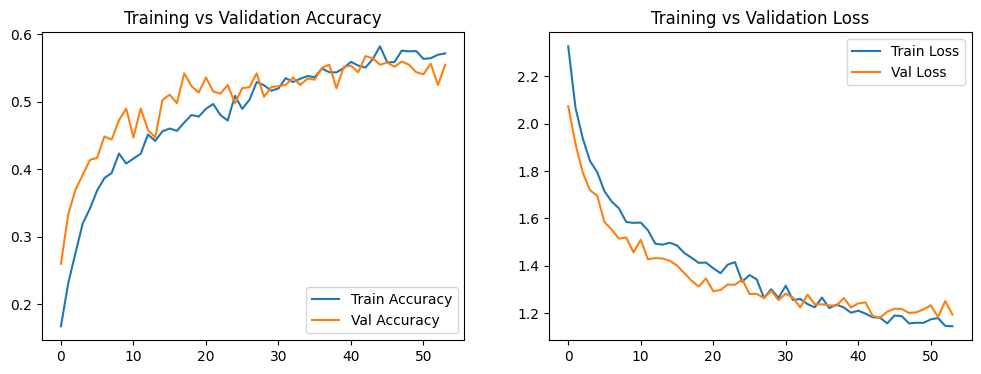

In [10]:
print("--- Final Model Evaluation (Test Set) ---")

# Evaluate the model on the unseen test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print(f"\nFinal Test Results:")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Optional: Plotting the training history to see the "Story" of the learning
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 279ms/step


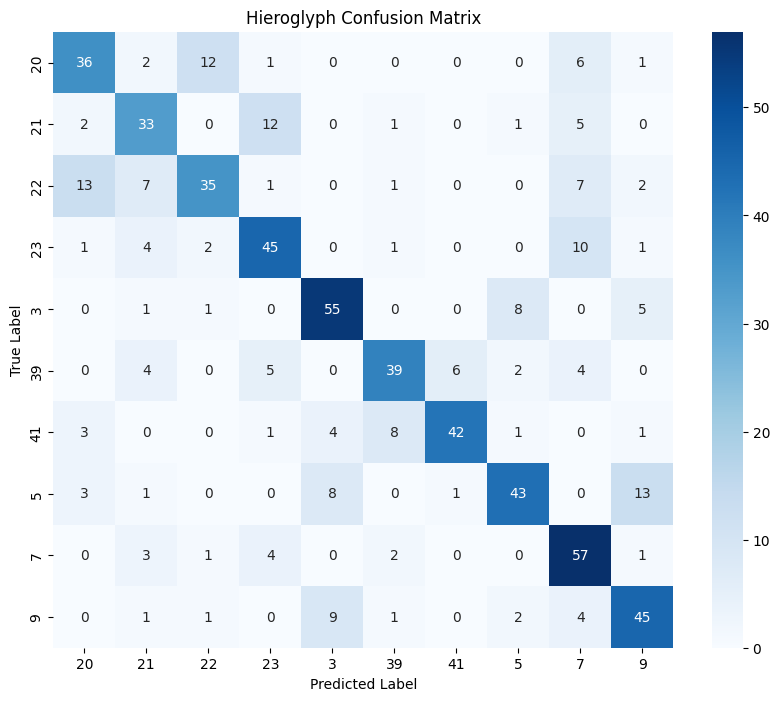


--- Detailed Classification Report ---
              precision    recall  f1-score   support

          20       0.62      0.62      0.62        58
          21       0.59      0.61      0.60        54
          22       0.67      0.53      0.59        66
          23       0.65      0.70      0.68        64
           3       0.72      0.79      0.75        70
          39       0.74      0.65      0.69        60
          41       0.86      0.70      0.77        60
           5       0.75      0.62      0.68        69
           7       0.61      0.84      0.71        68
           9       0.65      0.71      0.68        63

    accuracy                           0.68       632
   macro avg       0.69      0.68      0.68       632
weighted avg       0.69      0.68      0.68       632



In [11]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get Model Predictions
# The model outputs probabilities, so we use argmax to get the most likely class ID
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Generate the Confusion Matrix
# We use the original label names (Gardiner codes) for the axis
cm = confusion_matrix(y_test, y_pred)
class_names = list(le.classes_) # These are our 10 hieroglyph names

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Hieroglyph Confusion Matrix')
plt.show()

# 3. Per-Class Accuracy & Detailed Report
print("\n--- Detailed Classification Report ---")
# This shows Precision, Recall, and F1-Score for every single class
print(classification_report(y_test, y_pred, target_names=class_names))

In [12]:
# --- BLOCK 1: EFFICIENTNETB0 TRANSFER LEARNING ---
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet_model(input_shape, num_classes):
    # 1. Load EfficientNetB0 with ImageNet weights
    base_model_eff = EfficientNetB0(weights='imagenet', 
                                    include_top=False, 
                                    input_shape=input_shape)

    # 2. Freeze the base model
    base_model_eff.trainable = False

    # 3. Build the model
    model_eff = models.Sequential([
        layers.Input(shape=input_shape),
        # EfficientNet handles its own preprocessing/scaling internally!
        base_model_eff,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model_eff.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    
    return model_eff, base_model_eff

# Initialize the model
model_eff, base_model_eff = build_efficientnet_model(input_shape, num_classes)

# Display the summary
model_eff.summary()

# Train the model
print("Starting Training with EfficientNetB0 Transfer Learning...")
history_eff = model_eff.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=100, 
    callbacks=[early_stop], # Re-using your early stopping callback
    shuffle=True,
    verbose=1
)

print("EfficientNetB0 Training Complete!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

...

24/93 ━━━━━━━━━━━━━━━━━━━━ 20s 297ms/step - accuracy: 0.1306 - loss: 2.4140

2026-03-12 02:38:43.530720: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 02:38:43.665622: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 02:38:43.974857: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 02:38:44.116231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 02:38:44.824110: E external/local_xla/xla/stream_

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.1424 - loss: 2.3461

2026-03-12 02:39:23.623687: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 02:39:23.765253: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 02:39:24.105311: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 02:39:24.247200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 02:39:24.967669: E external/local_xla/xla/stream_

93/93 ━━━━━━━━━━━━━━━━━━━━ 85s 637ms/step - accuracy: 0.1426 - loss: 2.3452 - val_accuracy: 0.2393 - val_loss: 2.1038
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 30s 320ms/step - accuracy: 0.2545 - loss: 2.0550 - val_accuracy: 0.2821 - val_loss: 1.9661
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 315ms/step - accuracy: 0.3182 - loss: 1.8924 - val_accuracy: 0.3106 - val_loss: 1.8774
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 30s 317ms/step - accuracy: 0.3576 - loss: 1.8040 - val_accuracy: 0.3502 - val_loss: 1.7950
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 30s 318ms/step - accuracy: 0.4161 - loss: 1.6719 - val_accuracy: 0.3597 - val_loss: 1.7771
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 30s 318ms/step - accuracy: 0.4071 - loss: 1.6600 - val_accuracy: 0.3708 - val_loss: 1.7151
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 315ms/step - accuracy: 0.4256 - loss: 1.5560 - val_accuracy: 0.4025 - val_loss: 1.6551
Epoch 8/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 30s 320ms/step - accuracy: 0.4532 - loss: 1.5366 - val_accuracy

In [13]:
# --- BLOCK 2: EFFICIENTNETB0 FINE-TUNING PHASE ---

# 1. Unfreeze the base model
base_model_eff.trainable = True

# 2. Re-freeze most of the model, keeping only the top ~20 layers unfrozen
for layer in base_model_eff.layers[:-20]:
    layer.trainable = False

# 3. Re-compile with a VERY SMALL learning rate
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Fine-Tuning for EfficientNetB0 (Phase 2)...")

# 4. Train again
history_fine_eff = model_eff.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=30, 
    callbacks=[early_stop], 
    shuffle=True,
    verbose=1
)

print("EfficientNetB0 Fine-Tuning Complete!")

Starting Fine-Tuning for EfficientNetB0 (Phase 2)...
Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 75s 546ms/step - accuracy: 0.4378 - loss: 1.7015 - val_accuracy: 0.4406 - val_loss: 1.6689
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 314ms/step - accuracy: 0.4466 - loss: 1.5840 - val_accuracy: 0.4168 - val_loss: 1.7265
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 315ms/step - accuracy: 0.4736 - loss: 1.4919 - val_accuracy: 0.4152 - val_loss: 1.7418
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 316ms/step - accuracy: 0.4928 - loss: 1.4813 - val_accuracy: 0.4168 - val_loss: 1.7259
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 316ms/step - accuracy: 0.4912 - loss: 1.3938 - val_accuracy: 0.4216 - val_loss: 1.7011
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 310ms/step - accuracy: 0.5221 - loss: 1.3256 - val_accuracy: 0.4263 - val_loss: 1.6828
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 314ms/step - accuracy: 0.5249 - loss: 1.3244 - val_accuracy: 0.4390 - val_loss: 1.6673
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 30s 32

--- Final EfficientNetB0 Model Evaluation (Test Set) ---
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5258 - loss: 1.3333

2026-03-12 03:12:26.853619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 03:12:26.996583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 03:12:27.339699: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 03:12:27.481123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-12 03:12:28.206585: E external/local_xla/xla/stream_

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 561ms/step - accuracy: 0.5256 - loss: 1.3335

Final Test Results (EfficientNetB0):
Test Accuracy: 0.5237 (52.37%)
Test Loss: 1.3353


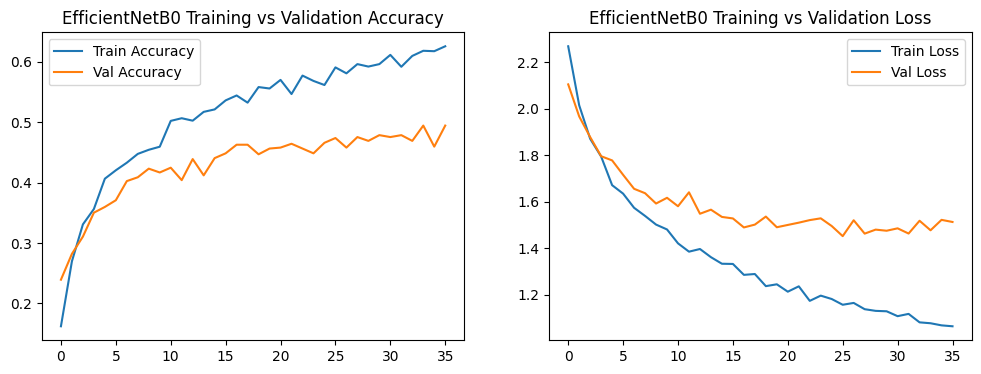

In [14]:
# --- BLOCK 3: FINAL MODEL EVALUATION & PLOTTING ---
print("--- Final EfficientNetB0 Model Evaluation (Test Set) ---")

# Evaluate the model on the unseen test data
test_loss_eff, test_acc_eff = model_eff.evaluate(X_test, y_test, verbose=1)

print(f"\nFinal Test Results (EfficientNetB0):")
print(f"Test Accuracy: {test_acc_eff:.4f} ({test_acc_eff * 100:.2f}%)")
print(f"Test Loss: {test_loss_eff:.4f}")

# Plotting the training history
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_eff.history['accuracy'], label='Train Accuracy')
plt.plot(history_eff.history['val_accuracy'], label='Val Accuracy')
plt.title('EfficientNetB0 Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_eff.history['loss'], label='Train Loss')
plt.plot(history_eff.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB0 Training vs Validation Loss')
plt.legend()

plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 363ms/step


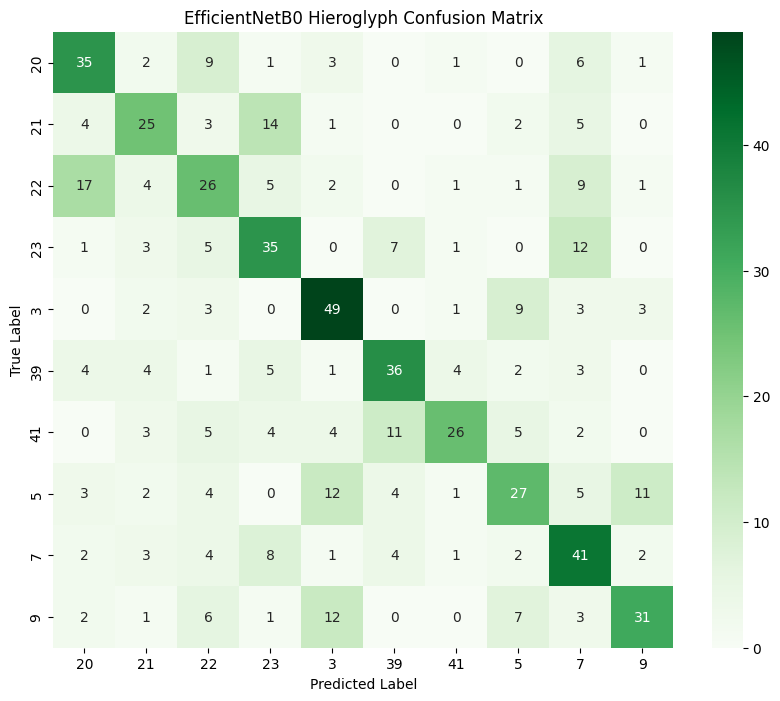


--- Detailed Classification Report (EfficientNetB0) ---
              precision    recall  f1-score   support

          20       0.51      0.60      0.56        58
          21       0.51      0.46      0.49        54
          22       0.39      0.39      0.39        66
          23       0.48      0.55      0.51        64
           3       0.58      0.70      0.63        70
          39       0.58      0.60      0.59        60
          41       0.72      0.43      0.54        60
           5       0.49      0.39      0.44        69
           7       0.46      0.60      0.52        68
           9       0.63      0.49      0.55        63

    accuracy                           0.52       632
   macro avg       0.54      0.52      0.52       632
weighted avg       0.53      0.52      0.52       632



In [15]:
# --- BLOCK 4: CONFUSION MATRIX & METRICS ---
# 1. Get Model Predictions
y_pred_probs_eff = model_eff.predict(X_test)
y_pred_eff = np.argmax(y_pred_probs_eff, axis=1)

# 2. Generate the Confusion Matrix
cm_eff = confusion_matrix(y_test, y_pred_eff)

plt.figure(figsize=(10, 8))
# Changed cmap to 'Greens' so you can easily distinguish this plot from the ResNet one
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('EfficientNetB0 Hieroglyph Confusion Matrix')
plt.show()

# 3. Per-Class Accuracy & Detailed Report
print("\n--- Detailed Classification Report (EfficientNetB0) ---")
print(classification_report(y_test, y_pred_eff, target_names=class_names))